#Imports and Set-Up

In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

#For neat plots
sns.set_theme(style = "whitegrid", palette = "muted")
plt.rcParams.update({'figure.dpi' : 130, 'axes.titlesize':13,
                     'axes.labelsize':11,
                     'xtick.labelsize': 9,'ytick.labelsize': 9,})

fearcolor = "#E33724"
greedcolor = "#18BE5D"

palette = {'Fear': fearcolor, 'Greed': greedcolor}


#**Part A: Data Preparation**

In [228]:
feargreed_path = '/content/fear_greed_index.csv'
historicaldata_path = '/content/historical_data.csv'

trades_raw    = pd.read_csv(historicaldata_path)
sentiment_raw = pd.read_csv(feargreed_path)

print(f"trades: {trades_raw.shape[0]:,} rows x {trades_raw.shape[1]} cols")
print(f"sentiment: {sentiment_raw.shape[0]:,} rows x {sentiment_raw.shape[1]} cols")

trades: 211,224 rows x 16 cols
sentiment: 2,644 rows x 4 cols


##Structure of trades data

In [229]:
trades_raw.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [230]:
trades_raw.dtypes

,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,object
Start Position,float64
Direction,object
Closed PnL,float64


In [231]:
missing_values = trades_raw.isnull().sum()[trades_raw.isnull().sum() > 0]
print("missing values in trades raw data:")
display(missing_values)

missing values in trades raw data:


,0


##Structure of sentiment data

In [232]:
sentiment_raw.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [233]:
sentiment_raw.dtypes

,0
timestamp,int64
value,int64
classification,object
date,object


In [234]:
missing_values = sentiment_raw.isnull().sum()
print("missing values in sentiment raw data:")
display(missing_values)

missing values in sentiment raw data:


,0
timestamp,0
value,0
classification,0
date,0


##Formatting Column and adjusting Date Column

In [235]:
trades_raw.columns = (
    trades_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s/]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)


sentiment_raw.columns = (
    sentiment_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s/]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

print('Trades cols   :', list(trades_raw.columns))
print('Sentiment cols:', list(sentiment_raw.columns))

Trades cols   : ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']
Sentiment cols: ['timestamp', 'value', 'classification', 'date']


In [236]:
#Adjusting and standardizing timestamp and date columns

TIMESTAMP_COL = [c for c in trades_raw.columns if 'time' in c][0]
print(f'Using timestamp column: "{TIMESTAMP_COL}"')
print('Sample values:', trades_raw[TIMESTAMP_COL].head(3).tolist())

trades_raw['datetime'] = pd.to_datetime(
    trades_raw[TIMESTAMP_COL],
    format='%d-%m-%Y %H:%M',   # ← explicit format
    errors='coerce'
)

# trades_raw['datetime'] = pd.to_datetime(
#     trades_raw[TIMESTAMP_COL],
#     infer_datetime_format=True,
#     errors='coerce'
# )
trades_raw['date'] = trades_raw['datetime'].dt.normalize()   # midnight UTC

bad_ts = trades_raw['datetime'].isna().sum()
print(f'\nUnparseable timestamps: {bad_ts}')
if bad_ts:
    print(trades_raw[trades_raw['datetime'].isna()][TIMESTAMP_COL].value_counts().head())

trades_raw = trades_raw.dropna(subset=['datetime'])  # drop rows with bad timestamps
print(f'Rows after dropping bad timestamps: {len(trades_raw):,}')

#No bad timestamps, all rows retained

Using timestamp column: "timestamp_ist"
Sample values: ['02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50']

Unparseable timestamps: 0
Rows after dropping bad timestamps: 211,224


In [237]:
#Adjusting and standardizing timestamp and date columns of Sentiment Table

DATE_COL_S = 'date' if 'date' in sentiment_raw.columns else 'timestamp'
print(f'Using sentiment date column: "{DATE_COL_S}"')
print('Sample values:', sentiment_raw[DATE_COL_S].head(3).tolist())

sentiment_raw['date'] = pd.to_datetime(
    sentiment_raw[DATE_COL_S],
    infer_datetime_format=True,
    errors='coerce'
).dt.normalize()

print(f'\nSentiment date range: {sentiment_raw["date"].min().date()} -> {sentiment_raw["date"].max().date()}')

Using sentiment date column: "date"
Sample values: ['2018-02-01', '2018-02-02', '2018-02-03']

Sentiment date range: 2018-02-01 -> 2025-05-02


##Simplification of trades_raw classification column

In [238]:
# Discretization of classification column - mapping extreme greed/fear to greed/fear

CLASS_COL = 'classification'
sentiment_raw[CLASS_COL] = (
    sentiment_raw[CLASS_COL]
    .str.strip()
    .str.title()
    .replace({
        'Extreme Fear' : 'Fear',
        'Extreme Greed': 'Greed',
        'Neutral'      : 'Neutral',   # keep neutral separately
    })
)

print('Sentiment label distribution:')
display(sentiment_raw[CLASS_COL].value_counts())

Sentiment label distribution:


,count
classification,
Fear,1289
Greed,959
Neutral,396


##De-duplication

In [239]:
# Trades: identify potential duplicate key
TRADE_ID_COL = [c for c in trades_raw.columns if 'trade_id' in c or 'hash' in c]
print('Candidate deduplicate columns (trades):', TRADE_ID_COL)

before = len(trades_raw)
if TRADE_ID_COL:
    trades_raw = trades_raw.drop_duplicates(subset=TRADE_ID_COL[0])
else:
    trades_raw = trades_raw.drop_duplicates()
print(f'Trades deduplicates: {before:,} --> {len(trades_raw):,} rows (removed {before - len(trades_raw):,})')


print("\nSentiment Data:")
# number of duplicate rows based on date
dup_count = sentiment_raw.duplicated(subset=['date']).sum()
print("Duplicate rows (by date):", dup_count)

# number of unique dates
unique_dates = sentiment_raw['date'].nunique()
print("Unique dates:", unique_dates)

before_s = len(sentiment_raw)
sentiment_raw = sentiment_raw.drop_duplicates(subset=['date'])
print(f'Sentiment deduplicates: {before_s} --> {len(sentiment_raw)} rows')

Candidate deduplicate columns (trades): ['transaction_hash', 'trade_id']
Trades deduplicates: 211,224 --> 101,184 rows (removed 110,040)

Sentiment Data:
Duplicate rows (by date): 0
Unique dates: 2644
Sentiment deduplicates: 2644 --> 2644 rows


##Standardizing and cleaning numeric attribute types

In [240]:
#First identifying numeric type

ACCOUNT_COL    = [c for c in trades_raw.columns if 'account' in c][0]
SIDE_COL       = [c for c in trades_raw.columns if 'side' in c][0]
PNL_COL        = [c for c in trades_raw.columns if 'pnl' in c or 'closedpnl' in c][0]
SIZE_USD_COL   = [c for c in trades_raw.columns if 'size_usd' in c or 'sizeusd' in c or ('size' in c and 'usd' in c)]
SIZE_USD_COL   = SIZE_USD_COL[0] if SIZE_USD_COL else None    #may be null or zero (or not exist) if the dataset provides the trade size in tokens of crypto currency or non usd equivalent
LEVERAGE_COL   = [c for c in trades_raw.columns if 'leverage' in c]
LEVERAGE_COL   = LEVERAGE_COL[0] if LEVERAGE_COL else None  # may be null or zero (or not exist) if the trading platform doesn't record leverage data (like spot traders have no leverage and hyperliquid data might omit it)
EXEC_PRICE_COL = [c for c in trades_raw.columns if 'execution' in c or 'price' in c][0]
SIZE_TOKEN_COL = [c for c in trades_raw.columns if 'size' in c and 'token' in c]
SIZE_TOKEN_COL = SIZE_TOKEN_COL[0] if SIZE_TOKEN_COL else None

print(f'account    : {ACCOUNT_COL}')
print(f'side       : {SIDE_COL}')
print(f'pnl        : {PNL_COL}')
print(f'size_usd   : {SIZE_USD_COL}')
print(f'leverage   : {LEVERAGE_COL}')
print(f'exec_price : {EXEC_PRICE_COL}')

# Coerce to numeric
num_cols = [c for c in [PNL_COL, SIZE_USD_COL, LEVERAGE_COL, EXEC_PRICE_COL, SIZE_TOKEN_COL] if c]
for col in num_cols:
    trades_raw[col] = pd.to_numeric(trades_raw[col], errors='coerce')

# Standardise side to UPPER
trades_raw[SIDE_COL] = trades_raw[SIDE_COL].str.strip().str.upper()

print('\n\nNumeric stats for key columns:')
display(trades_raw[num_cols].describe())

account    : account
side       : side
pnl        : closed_pnl
size_usd   : size_usd
leverage   : None
exec_price : execution_price


Numeric stats for key columns:


,closed_pnl,size_usd,execution_price,size_tokens
count,101184.000000,1.011840e+05,101184.000000,1.011840e+05
mean,56.954723,4.242173e+03,9926.197766,6.943248e+03
std,1101.825807,3.977517e+04,27796.209593,1.377028e+05
min,-117990.104100,0.000000e+00,0.000005,1.000000e-05
25%,0.000000,1.651475e+02,1.449000,3.330000e+00
50%,0.000000,5.261800e+02,16.818000,3.742000e+01
75%,4.032548,1.581787e+03,106.370000,3.044500e+02
max,135329.090100,3.921431e+06,109004.000000,1.582244e+07


##Merge sentiment and trades data on date

In [241]:
sentiment_slim = sentiment_raw[['date', CLASS_COL]].rename(columns={CLASS_COL: 'sentiment'})
#strips the sentiment table down to just two columns- date and classification - and renames classification to sentiment for cleaner column naming downstream.
trades = trades_raw.merge(sentiment_slim, on='date', how='left')  #left - ensures all trade rows are kept even if a matching sentiment date doesn't exist

unmatched = trades['sentiment'].isna().sum()
print(f'Total trade rows        : {len(trades):,}')
print(f'Rows with sentiment data: {(~trades["sentiment"].isna()).sum():,}')
print(f'Rows WITHOUT sentiment  : {unmatched:,}  ({100*unmatched/len(trades):.4f}%)')

#drop rows without a sentiment label for the main analysis
trades_m = trades.dropna(subset=['sentiment']).copy() #those unmatched rows just get NaN for sentiment and are dropped
print(f'\nWorking dataset size: {len(trades_m):,} rows')

Total trade rows        : 101,184
Rows with sentiment data: 101,181
Rows WITHOUT sentiment  : 3  (0.0030%)

Working dataset size: 101,181 rows


##Feature Creation (Key Metrics Engineering)

###1. Trade Type Flags

In [242]:
#Trade Type Flags

#flags trades that closed a position - if PnL is non-null or non-zero (as open trades have 0 or null PnL)
trades_m['is_close']    = trades_m[PNL_COL].notna() & (trades_m[PNL_COL] != 0)

#if PnL is positive then the trade is marked as profitable
trades_m['is_win']      = trades_m[PNL_COL] > 0

#if the trade's direction is long/bullish then it is standardized to be a buy position
trades_m['is_buy']      = trades_m[SIDE_COL].isin(['BUY', 'LONG'])

In [243]:
# Compute size in USD if missing
"""
Some datasets provide trade size in tokens (e.g. 0.5 BTC)
rather than USD,
so this block handles the case where a USD size column doesn't exist

essentially converting "how many tokens" into "how many dollars"
which is
multiplying the token size by the execution price
(the standard way to convert crypto quantity to dollar value)
"""

if SIZE_USD_COL is None and SIZE_TOKEN_COL:
    trades_m['size_usd'] = trades_m[SIZE_TOKEN_COL] * trades_m[EXEC_PRICE_COL]
    SIZE_USD_COL = 'size_usd'

In [244]:
print('Trade-level flags created')
print(f'  Closing trades (PnL != 0): {trades_m["is_close"].sum():,}')
print(f'  Winning trades           : {trades_m["is_win"].sum():,}')
print(f'  Buy trades               : {trades_m["is_buy"].sum():,}')

Trade-level flags created
  Closing trades (PnL != 0): 47,759
  Winning trades           : 40,290
  Buy trades               : 50,834


###2. Daily summary per trader

In [245]:
# Trader Aggregation - Daily summary per trader - One row per trader per day

#how each of the following columns should be summarized
agg_dict = {
    PNL_COL          : 'sum',
    'is_close'       : 'sum',   # n_closing_trades
    'is_win'         : 'sum',   # n_winning_trades
    'is_buy'         : 'mean',  # long ratio
    'sentiment'      : 'first',
}


if SIZE_USD_COL: #adding these columns to the agg only if they exist in the dataset
    agg_dict[SIZE_USD_COL] = ['mean', 'sum']
    print("Yes usd col")
if LEVERAGE_COL:
    agg_dict[LEVERAGE_COL] = 'mean'
    print("Yes leverage col")


daily_trader = (
    trades_m
    .groupby([ACCOUNT_COL, 'date'])  #groups by trader and date simultaneously
    .agg(agg_dict) #applies the agg col functions
)


Yes usd col


In [246]:
# Flatten multi-level columns

# like ['mean', 'sum'] for SIZE_USD_COL - pandas makes it tuple like
# ('size_usd', 'mean') --flattening step joins by _
daily_trader.columns = [
    '_'.join(c).strip('_') if isinstance(c, tuple) else c
    for c in daily_trader.columns
]
daily_trader = daily_trader.reset_index()

In [247]:
# Friendly column names
rename_map = {
    f'{PNL_COL}_sum'      : 'daily_pnl',
    'is_close_sum'        : 'n_trades',
    'is_win_sum'          : 'n_wins',
    'is_buy_mean'         : 'long_ratio',
    f'{SIZE_USD_COL}_mean': 'avg_trade_size',
    f'{SIZE_USD_COL}_sum' : 'total_volume',
    'sentiment_first'     : 'sentiment',
}
if LEVERAGE_COL:
    rename_map[f'{LEVERAGE_COL}_mean'] = 'avg_leverage'

daily_trader = daily_trader.rename(columns={k: v for k, v in rename_map.items() if k in daily_trader.columns})


In [248]:


#ratio of winning trades to total trades for each trader-day with div by 0 error handling (when no trader trades on a day)
daily_trader['win_rate']   = daily_trader['n_wins'] / daily_trader['n_trades'].replace(0, np.nan)

# Boolean flag if for that day that trader overall ended in profit or not
daily_trader['is_profitable'] = daily_trader['daily_pnl'] > 0

print('daily_trader shape:', daily_trader.shape)
display(daily_trader.head(3))

daily_trader shape: (2302, 11)


,account,date,daily_pnl,n_trades,n_wins,long_ratio,sentiment,avg_trade_size,total_volume,win_rate,is_profitable
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0,0,0.0,Greed,4375.614286,581956.70,NaN,False
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0,0,0.0,Greed,8281.199333,496871.96,NaN,False
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0,0,0.0,Greed,23734.500000,949380.00,NaN,False


###3. Trader wise summary

daily_trader: Is the table with one row per Trader per day [trader x day ] -- time *series* view

trader_summary: one row per trader across all time in the historical dataset [trader only] -- portfolio of each trader

In [249]:
#Per-trader summary (entire history)

# Lifetime stats of a trader
trader_summary = (
    daily_trader
    .groupby(ACCOUNT_COL)
    .agg(
        total_pnl         = ('daily_pnl',     'sum'),
        mean_daily_pnl    = ('daily_pnl',     'mean'),
        pnl_std           = ('daily_pnl',     'std'), #How volatile a trader;s daily PnL is
        total_trades      = ('n_trades',      'sum'),
        active_days       = ('date',          'nunique'), #how many distinct days trader was active which is different from total_trades since trader may execute multiple trades on the same day
        overall_win_rate  = ('win_rate',      'mean'), #singletime measure of how often a trader closes profitable trades on an average day
        mean_long_ratio   = ('long_ratio',    'mean'),
    )
)

if 'avg_leverage' in daily_trader.columns:
    lev_summary = daily_trader.groupby(ACCOUNT_COL)['avg_leverage'].mean().rename('mean_leverage')
    trader_summary = trader_summary.join(lev_summary)

if 'avg_trade_size' in daily_trader.columns:
    sz_summary = daily_trader.groupby(ACCOUNT_COL)['avg_trade_size'].mean().rename('mean_trade_size')
    trader_summary = trader_summary.join(sz_summary)

# Drawdown proxy= max cumulative loss
# Calculates the worst cumulative loss streak a trader experienced
# (proxy - as we take PnL snapshots and not everyday's intra day price data)
def max_drawdown_proxy(series):  # trader's daily PnL series
    cum = series.cumsum()
    return (cum - cum.cummax()).min()  #difference between trough to prev peak

drawdown = (
    daily_trader
    .sort_values([ACCOUNT_COL, 'date']) #needs to be chronological for drawdown
    .groupby(ACCOUNT_COL)['daily_pnl']
    .apply(max_drawdown_proxy)
    .rename('drawdown_proxy')
)
trader_summary = trader_summary.join(drawdown).reset_index() # a single life-time worst metric to identify risk prone traders
#more negative --> worse

print('trader_summary shape:', trader_summary.shape)
# only 10 columns as sentiment column is collapsed on a overall
#historic dataset span view during aggression

display(trader_summary.describe())

trader_summary shape: (32, 10)


,total_pnl,mean_daily_pnl,pnl_std,total_trades,active_days,overall_win_rate,mean_long_ratio,mean_trade_size,drawdown_proxy
count,3.200000e+01,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,1.790929e+05,4198.798213,14421.877400,1492.468750,71.937500,0.845000,0.491646,11041.633864,-24828.448287
std,2.782201e+05,9271.809501,27095.330662,1796.162755,73.149841,0.115076,0.136158,12420.303977,59341.891497
min,-1.738917e+04,-1580.833325,621.025793,11.000000,11.000000,0.525794,0.227866,493.810607,-328438.414567
25%,1.621204e+04,348.226732,1852.853553,265.000000,25.500000,0.782685,0.402794,3055.619992,-23478.331600
50%,7.692912e+04,1497.234951,5356.782844,708.500000,46.500000,0.853900,0.477906,5198.083554,-6226.939760
75%,1.893499e+05,4281.951134,16895.058978,1545.500000,74.750000,0.924088,0.565732,14314.079829,-673.881462
max,1.173356e+06,48889.846465,138465.530359,6465.000000,321.000000,1.000000,0.798332,52804.247718,0.000000


#**Part B: Analysis and Interpretation**

##1. Performance on Fear vs Greed Days

In [250]:
# Filter to Fear / Greed only
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

perf_cols = ['daily_pnl', 'win_rate']
if 'drawdown_proxy' in daily_trader.columns:
    pass  # drawdown is in trader_summary; skip here

perf_by_sentiment = fg.groupby('sentiment')[perf_cols].agg(['mean', 'median', 'std'])
print('Performance by Sentiment')
display(perf_by_sentiment)

Performance by Sentiment


daily_pnl                           win_rate                 
                  mean     median           std      mean median       std
sentiment                                                                 
Fear       3025.030903  36.800000  25043.307707  0.848037    1.0  0.297520
Greed      2554.452422  77.720071  19805.045698  0.863884    1.0  0.269625

Interpretation: Fear days show higher mean PnL (usd 3025) but lower median (36.8) which implies a skewed pattern where Fear- day profits are driven by few outlier traders than broad profitability

Win Rates are identical across both Fear and Greed but the higher PnL std on Fear days (25k usd vs 19.8k usd) confirms some disparity - fear days produce more extreme winners and losers alike.

In [251]:
#Statistical Test according to sentiment

fear_pnl  = fg.loc[fg['sentiment'] == 'Fear',  'daily_pnl'].dropna()
greed_pnl = fg.loc[fg['sentiment'] == 'Greed', 'daily_pnl'].dropna()

t_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f'Mann-Whitney U test - Daily PnL (Fear vs Greed)')
print(f'  U = {t_stat:.2f},  p = {p_val:.4f}  → {"Significant" if p_val < 0.05 else "Not significant"} at α=0.05')

Mann-Whitney U test - Daily PnL (Fear vs Greed)
  U = 420960.00,  p = 0.0198  → Significant at α=0.05


This test checks if both Fear day and Greed day values are drawn from the same distribution fundamentally to ensure that they are meaningfully different. If not they are chance random difference based gaps.

Mann-Whitney test because PnL data was seen to be skewed with outlier traders and this test doesn't assume normal distribution unlike t-tests. It workks by ranking all values together and checking if one group's ranks are systematically higher than other's.

p=0.0198 means there is only a 1.98% probability of seeing a difference based on random chance. Plus, p<0.05 which means nul hypothesis can be rejected.


interpretation of results:
A Mann-Whitney U test confirms the PnL difference between Fear and Greed days is statistically significant (U=420,960, p=0.0198), meaning the behavioral gap is real and not attributable to random variation.


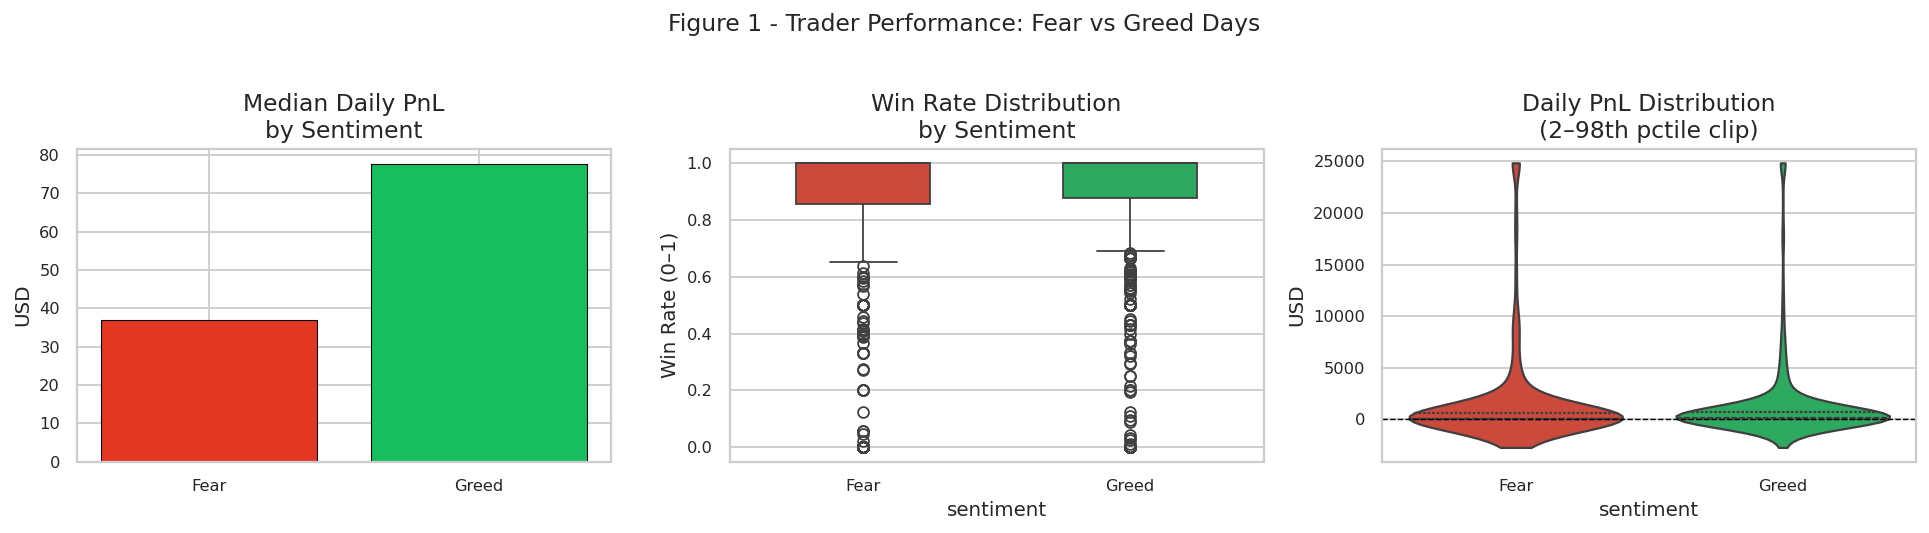

In [252]:
# Visualisation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Median daily PnL
med_pnl = fg.groupby('sentiment')['daily_pnl'].median()
axes[0].bar(med_pnl.index, med_pnl.values,
            color=[palette[s] for s in med_pnl.index], edgecolor='black', linewidth=0.6)
axes[0].set_title('Median Daily PnL\nby Sentiment')
axes[0].set_ylabel('USD')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# (b) Win rate distribution
sns.boxplot(data=fg, x='sentiment', y='win_rate', palette=palette,
            order=['Fear', 'Greed'], ax=axes[1], width=0.5)
axes[1].set_title('Win Rate Distribution\nby Sentiment')
axes[1].set_ylabel('Win Rate (0–1)')

# (c) PnL violin
fg_clipped = fg.copy()
fg_clipped['daily_pnl'] = fg_clipped['daily_pnl'].clip(
    fg_clipped['daily_pnl'].quantile(0.02),
    fg_clipped['daily_pnl'].quantile(0.98)
)
sns.violinplot(data=fg_clipped, x='sentiment', y='daily_pnl', palette=palette,
               order=['Fear', 'Greed'], ax=axes[2], inner='quartile', cut=0)
axes[2].set_title('Daily PnL Distribution\n(2–98th pctile clip)')
axes[2].set_ylabel('USD')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Figure 1 - Trader Performance: Fear vs Greed Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig1_performance_by_sentiment.png', bbox_inches='tight')
plt.show()

Chart A:
Median Daily PnL Bar Chart:
Simply plots the median PnL for Fear vs Greed days. Greed days (~$77) are clearly more profitable for a trader than fear days where the median PnL is usd 37. Median instead of mean as we want to avoid distortion due to outliers.

Chart B:
Win Rate Distribution boxplot: Shows the spread of win rates across all trader-days for each sentiment. Both boxes sit high (0.85–1.0) meaning most traders win most of their trades regardless of sentiment. However, Fear has more outliers scattered low, meaning a subset of traders fall apart on Fear days.

Chart C:
Daily PnL Distribution violin plot: The PnL is clipped to the 2nd–98th percentile first to remove extreme outliers that would squash the shape. The violin's width at any point shows how many traders had that PnL value - both are fat near zero (most traders make small amounts), but Fear's violin stretches much wider upward, confirming more variance/extreme outcomes on Fear days.

Conclusion:
Greed days produce a higher median daily PnL (usd 77.7 vs usd 36.8) with a tighter win rate distribution, suggesting more consistent profitability across traders compared to Fear days.
The wider Fear-day violin confirms greater outcome disparity. While most traders cluster near zero PnL on both regimes, Fear days generate more extreme results in both directions, consistent with the higher standard deviation observed in the summary statistics.


##2. Behavioral Changes Under Fear vs Greed

In [253]:
behavior_cols = ['n_trades', 'long_ratio']
if 'avg_leverage' in fg.columns:
    behavior_cols.append('avg_leverage')
if 'avg_trade_size' in fg.columns:
    behavior_cols.append('avg_trade_size')

behavior_by_sentiment = fg.groupby('sentiment')[behavior_cols].agg(['mean', 'median'])
print('Behavior by Sentiment')
display(behavior_by_sentiment)

Behavior by Sentiment


n_trades        long_ratio           avg_trade_size             
                mean median       mean    median           mean       median
sentiment                                                                   
Fear       21.256145    3.0   0.544027  0.538462   10924.904993  2213.306842
Greed      21.221361    2.0   0.478951  0.500000    6450.163608  1912.454286

Traders are equally active on both Fear and Greed days (21 trades per day_ but show a slight long bias or bullish bias on Fear days (54% long) vs. a almost neutral stance on Greed days (48% long). All this while trade sizes are notably larger on Fear days (usd 10,924 mean vs usd 6,450) suggesting traders take bigger but more directionally confused positions when the market is fearful.

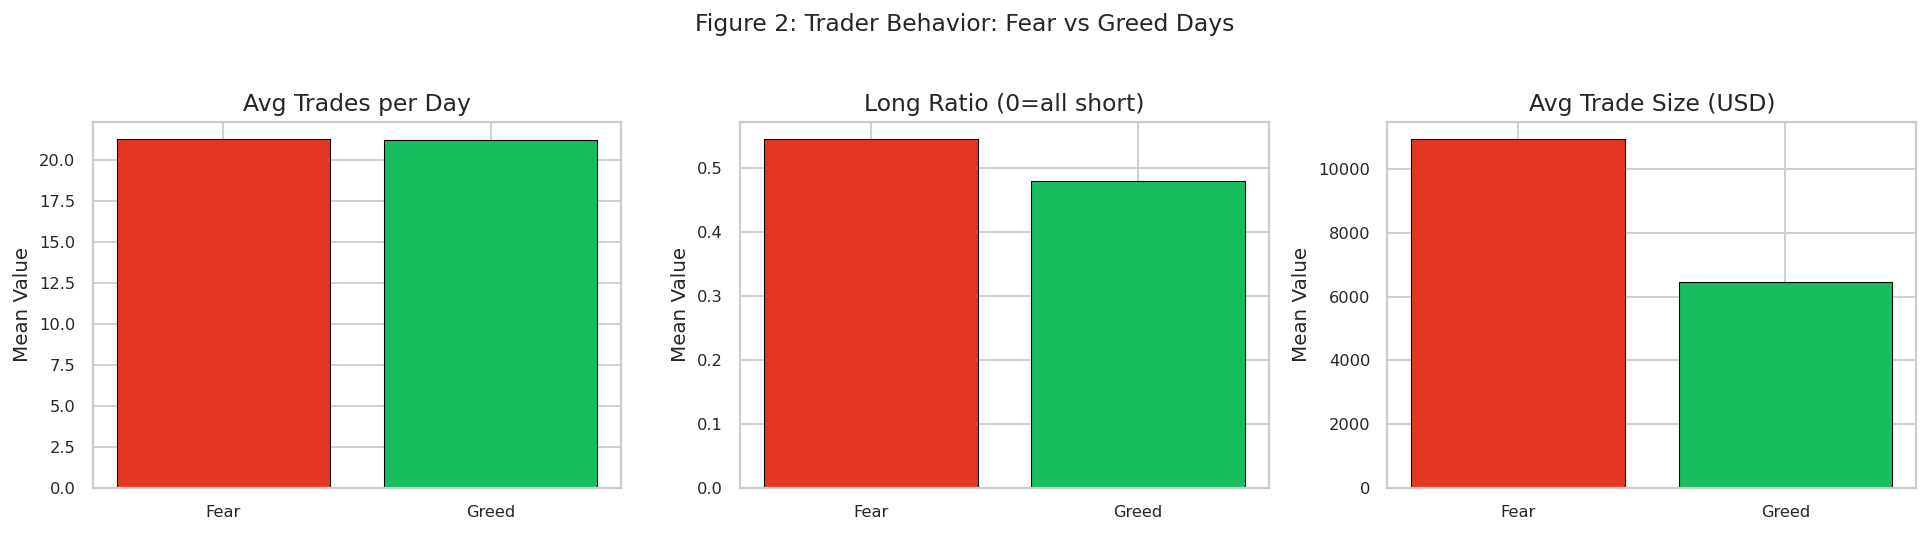

In [254]:
n_plot = len(behavior_cols)
fig, axes = plt.subplots(1, n_plot, figsize=(5 * n_plot, 4))
if n_plot == 1:
    axes = [axes]

titles = {
    'n_trades'       : 'Avg Trades per Day',
    'long_ratio'     : 'Long Ratio (0=all short)',
    'avg_leverage'   : 'Avg Leverage',
    'avg_trade_size' : 'Avg Trade Size (USD)',
}

for ax, col in zip(axes, behavior_cols):
    means = fg.groupby('sentiment')[col].mean()
    ax.bar(means.index, means.values,
           color=[palette[s] for s in means.index], edgecolor='black', linewidth=0.6)
    ax.set_title(titles.get(col, col))
    ax.set_ylabel('Mean Value')

plt.suptitle('Figure 2: Trader Behavior: Fear vs Greed Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig2_behavior_by_sentiment.png', bbox_inches='tight')
plt.show()

Interpretation:



*   Trade frequency is virtually identical across Fear and Greed days (~21 trades/day), confirming that sentiment doesn't affect how often traders execute
*   On Fear days traders lean slightly long (54%) while on Greed days they shift closer to neutral (48%), which is counterintuitive as one would expect more bullish positioning during Greed, however the turn of how fear is, is suggesting traders may be hedging or buying dips during fearful periods.
*   The most striking difference is trade size: Fear day positions are ~69% larger (usd 10,924 vs usd 6,450), indicating traders deploy significantly more capital per trade when the market is fearful, possibly attempting to capitalize on perceived dip-buying opportunities but simultaneously taking on more risk.

##3. Segmentation of Traders

###i. Based on Leverage: High vs. Low


In [255]:
if 'mean_leverage' in trader_summary.columns:
    lev_med = trader_summary['mean_leverage'].median()
    trader_summary['leverage_segment'] = np.where(
        trader_summary['mean_leverage'] >= lev_med, 'High Leverage', 'Low Leverage'
    )
    print(f'Leverage median = {lev_med:.1f}x')
    print(trader_summary['leverage_segment'].value_counts())
else:
    # Fallback: segment by trade size
    if 'mean_trade_size' in trader_summary.columns:
        sz_med = trader_summary['mean_trade_size'].median()
        trader_summary['leverage_segment'] = np.where(
            trader_summary['mean_trade_size'] >= sz_med, 'Large Size', 'Small Size'
        )
    print('No leverage column found, segmented by trade size instead.')
    print(trader_summary['leverage_segment'].value_counts())

No leverage column found, segmented by trade size instead.
leverage_segment
Large Size    16
Small Size    16
Name: count, dtype: int64


since the Hyperliquid dataset has no leverage column, the code falls back to splitting traders by their mean trade size at the median, giving 16 large-size and 16 small-size traders out of the 32 total unique traders. ( traders deploying larger position sizes per trade are effectively taking on more risk per trade, similar to high leverage players)

In [256]:
# Merge segment back into daily_trader for sentiment breakdown
daily_trader = daily_trader.merge(
    trader_summary[[ACCOUNT_COL, 'leverage_segment']],
    on=ACCOUNT_COL, how='left'
)
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

seg1_perf = (
    fg.groupby(['leverage_segment', 'sentiment'])[['daily_pnl', 'win_rate']]
    .mean()
    .round(4)
)
print('Segment 1: Leverage x Sentiment')
display(seg1_perf)

Segment 1: Leverage x Sentiment


daily_pnl  win_rate
leverage_segment sentiment                     
Large Size       Fear       6337.3000    0.8620
                 Greed      2181.0883    0.9012
Small Size       Fear       1003.1666    0.8405
                 Greed      2725.6558    0.8512

--> Large-size traders are highly sentiment-sensitive.

--> They exploit panic (fear) driven volatility but perform poorer when market is complacent.

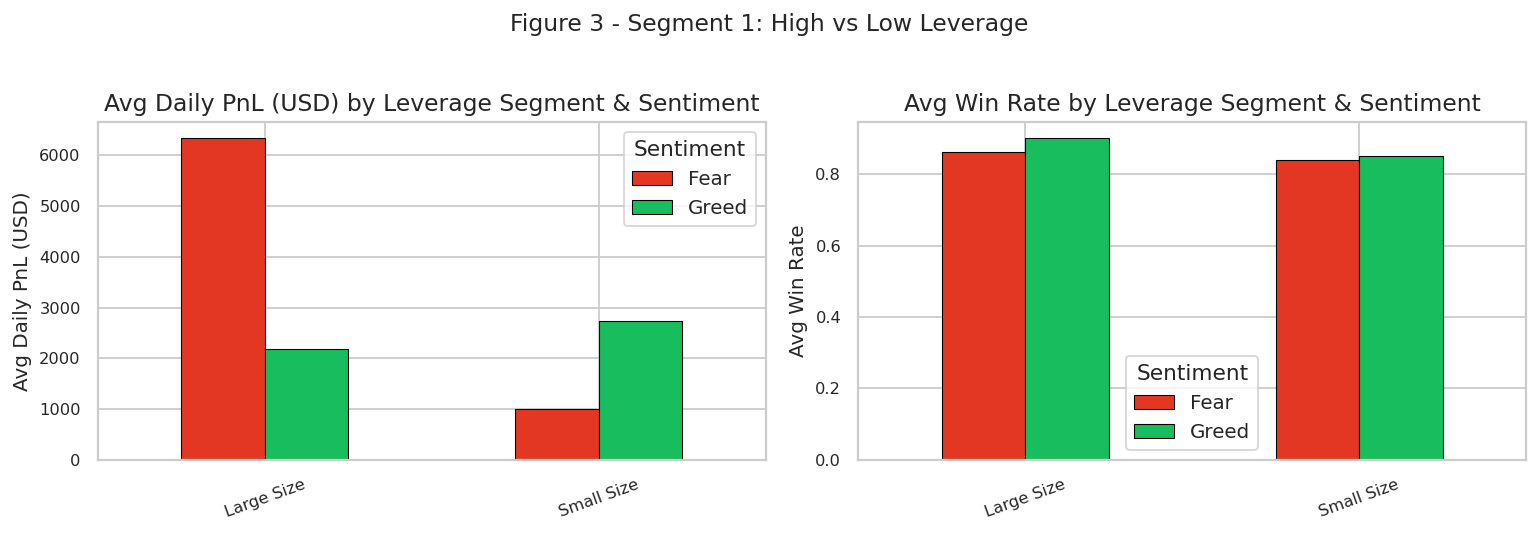

In [257]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in zip(axes, ['daily_pnl', 'win_rate'], ['Avg Daily PnL (USD)', 'Avg Win Rate']):
    pivot = seg1_perf[metric].unstack('sentiment')[['Fear', 'Greed']]
    pivot.plot(kind='bar', ax=ax, color=[fearcolor, greedcolor], edgecolor='black', linewidth=0.6)
    ax.set_title(f'{ylabel} by Leverage Segment & Sentiment')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.legend(title='Sentiment')

plt.suptitle('Figure 3 - Segment 1: High vs Low Leverage', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig3_leverage_segment.png', bbox_inches='tight')
plt.show()

--> Large-size traders earn 3x more on Fear days than Greed days

--> small-size traders do the opposite (better on Greed days)

--> and win rates remain high across both segments implying PnL gap is driven by position sizing and volatility capture rather than trade accuracy

###ii. Trade Frequency: Frequent vs Infrequent Traders

In [258]:
freq_med = trader_summary['total_trades'].median()
trader_summary['freq_segment'] = np.where(
    trader_summary['total_trades'] >= freq_med, 'Frequent', 'Infrequent'
)
print(f'Trade count median = {freq_med:.0f}')
print(trader_summary['freq_segment'].value_counts())

daily_trader = daily_trader.merge(
    trader_summary[[ACCOUNT_COL, 'freq_segment']],
    on=ACCOUNT_COL, how='left'
)
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

seg2_perf = (
    fg.groupby(['freq_segment', 'sentiment'])[['daily_pnl', 'win_rate']]
    .mean()
    .round(4)
)
print('\nSegment 2: Frequency x Sentiment')
display(seg2_perf)

Trade count median = 708
freq_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

Segment 2: Frequency x Sentiment


daily_pnl  win_rate
freq_segment sentiment                     
Frequent     Fear       3743.8285    0.8542
             Greed      2771.6041    0.8355
Infrequent   Fear       1457.2831    0.8320
             Greed      2146.0132    0.9454

Frequent traders dominate on Fear days (3.7k usd vs 1.4k usd) while infrequent traders outperform on Greedy days (by a smaller margin)

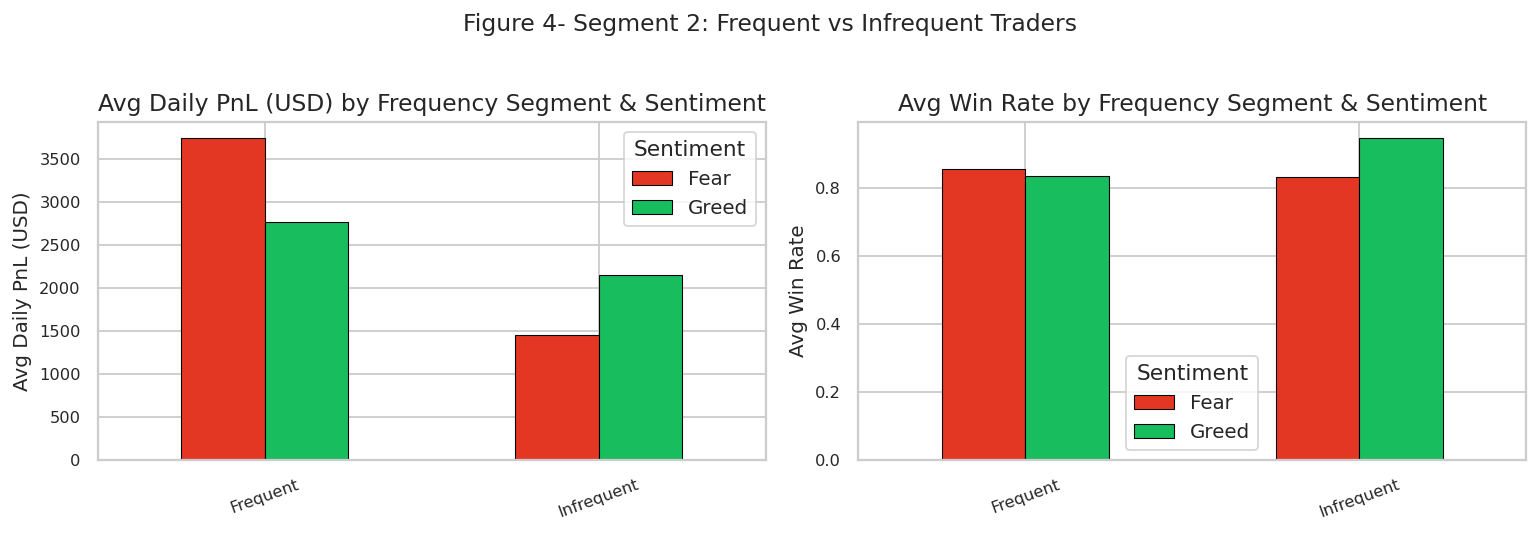

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in zip(axes, ['daily_pnl', 'win_rate'], ['Avg Daily PnL (USD)', 'Avg Win Rate']):
    pivot = seg2_perf[metric].unstack('sentiment')[['Fear', 'Greed']]
    pivot.plot(kind='bar', ax=ax, color=[fearcolor, greedcolor], edgecolor='black', linewidth=0.6)
    ax.set_title(f'{ylabel} by Frequency Segment & Sentiment')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.legend(title='Sentiment')

plt.suptitle('Figure 4- Segment 2: Frequent vs Infrequent Traders', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig4_frequency_segment.png', bbox_inches='tight')
plt.show()

Infrequent traders show a more notable jump in win rate on Greed days (94.5%) suggesting they are highly selective who wait for trending conditions before entering. While frequent traders grind out profits through volume regardless of sentiment.

###iii. Consistent Winners vs Inconsistent Winners

In [260]:
wr_med  = trader_summary['overall_win_rate'].median()
std_med = trader_summary['pnl_std'].median()

def classify_consistency(row):
    if row['overall_win_rate'] >= wr_med and row['pnl_std'] <= std_med:
        return 'Consistent Winner'
    elif row['overall_win_rate'] < wr_med and row['pnl_std'] > std_med:
        return 'Inconsistent Loser'
    else:
        return 'Mixed'

trader_summary['consistency_segment'] = trader_summary.apply(classify_consistency, axis=1)
print(trader_summary['consistency_segment'].value_counts())

daily_trader = daily_trader.merge(
    trader_summary[[ACCOUNT_COL, 'consistency_segment']],
    on=ACCOUNT_COL, how='left'
)
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

seg3_perf = (
    fg.groupby(['consistency_segment', 'sentiment'])[['daily_pnl', 'win_rate']]
    .mean()
    .round(4)
)
print('\nSegment 3: Consistency x Sentiment')
display(seg3_perf)

consistency_segment
Mixed                 12
Inconsistent Loser    10
Consistent Winner     10
Name: count, dtype: int64

Segment 3: Consistency x Sentiment


daily_pnl  win_rate
consistency_segment sentiment                     
Consistent Winner   Fear        392.9001    0.9023
                    Greed      1064.3323    0.9283
Inconsistent Loser  Fear       6484.7515    0.8173
                    Greed      6000.0924    0.7700
Mixed               Fear       2218.1892    0.8303
                    Greed      1466.3744    0.8497

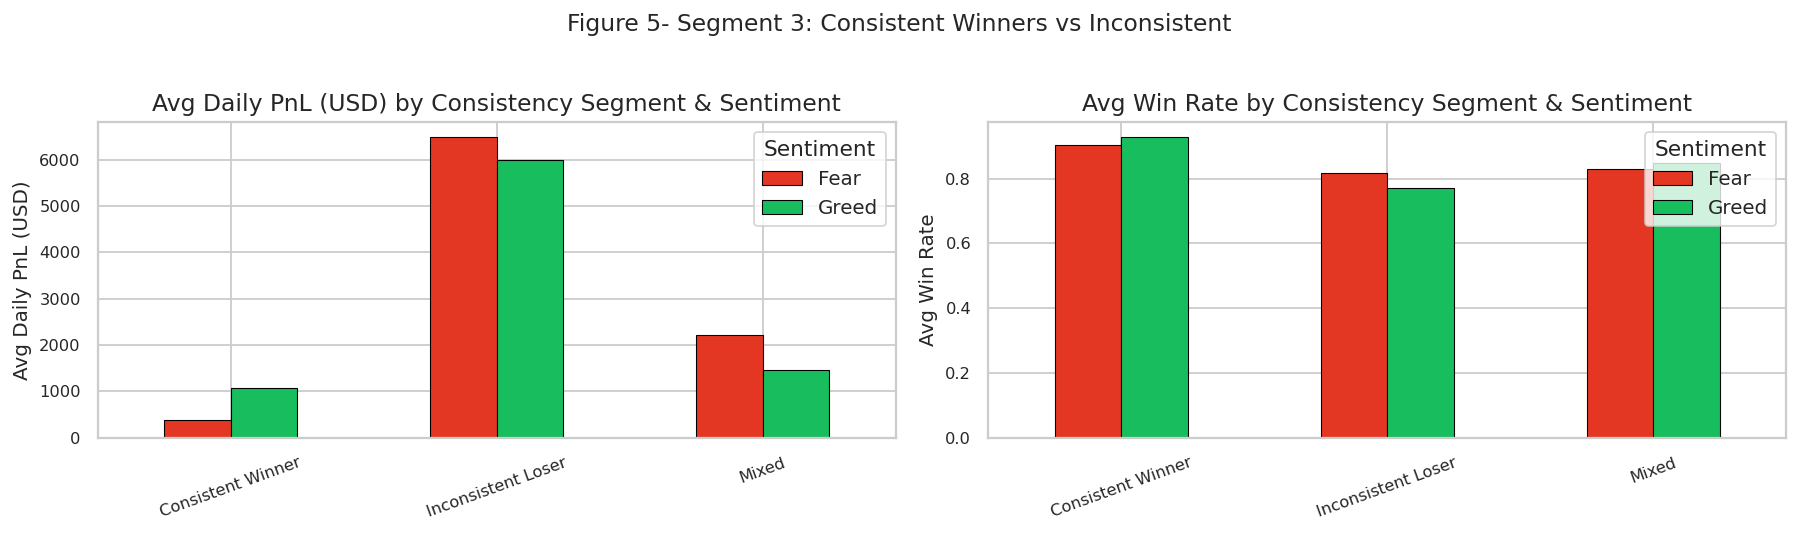

In [261]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, ylabel in zip(axes, ['daily_pnl', 'win_rate'], ['Avg Daily PnL (USD)', 'Avg Win Rate']):
    pivot = seg3_perf[metric].unstack('sentiment')
    for col in ['Fear', 'Greed']:
        if col not in pivot.columns:
            pivot[col] = np.nan
    pivot = pivot[['Fear', 'Greed']]
    pivot.plot(kind='bar', ax=ax, color=[fearcolor, greedcolor], edgecolor='black', linewidth=0.6)
    ax.set_title(f'{ylabel} by Consistency Segment & Sentiment')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.legend(title='Sentiment')

plt.suptitle('Figure 5- Segment 3: Consistent Winners vs Inconsistent', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig5_consistency_segment.png', bbox_inches='tight')
plt.show()

--> Inconsistent Losers generate the highest PnL despite having the lowest win rates of 77%-82% - implies they are high-risk, large position traders.

--> Consistent Winners show the opposite where they have good win rates but moderate PnL's which implies that they trade small and safe but never risky enough to swing large.

##4. Other Insights

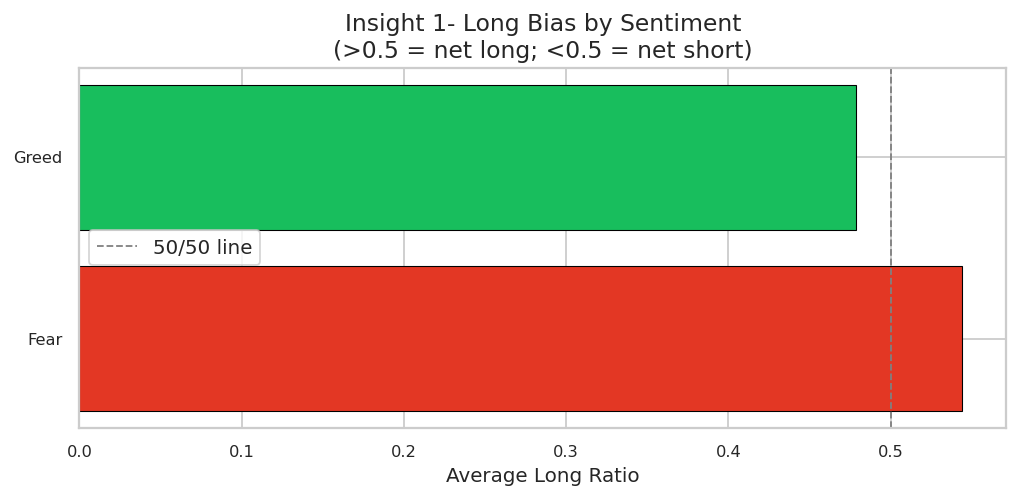

In [262]:
#Insight 1: Long/Short bias shifts with sentiment
fig, ax = plt.subplots(figsize=(8, 4))
long_ratio_by_sent = fg.groupby('sentiment')['long_ratio'].mean()

bars = ax.barh(
    long_ratio_by_sent.index,
    long_ratio_by_sent.values,
    color=[palette[s] for s in long_ratio_by_sent.index],
    edgecolor='black', linewidth=0.6
)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, label='50/50 line')
ax.set_xlabel('Average Long Ratio')
ax.set_title('Insight 1- Long Bias by Sentiment\n(>0.5 = net long; <0.5 = net short)')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_long_bias.png', bbox_inches='tight')
plt.show()

Traders are net long during Fear (54%) and net short during Greed (48%) --> Contrarian dip-buyers (not momentum followers)

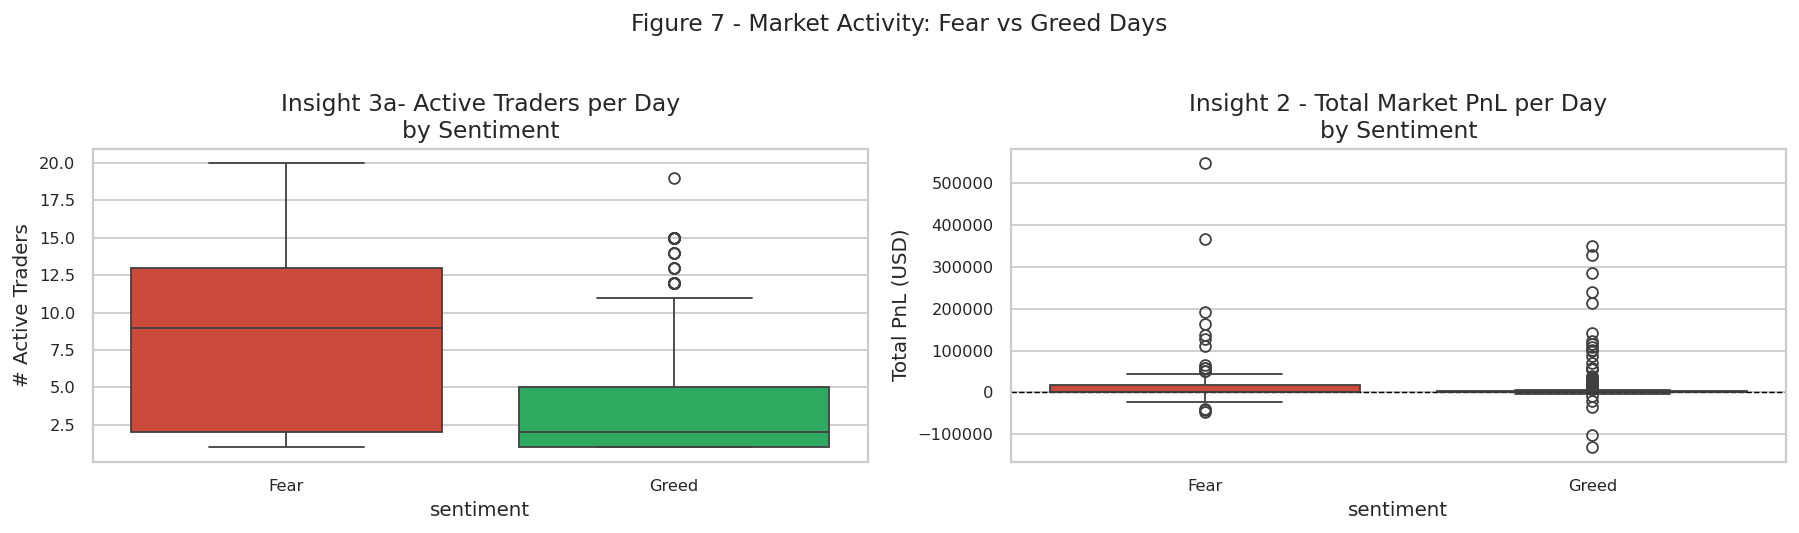

In [263]:
# Insight 2: Trade-day count (market activity) by sentiment
daily_agg = (
    fg.groupby(['date', 'sentiment'])
    .agg(total_traders=('daily_pnl', 'count'),
         total_pnl=('daily_pnl', 'sum'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=daily_agg, x='sentiment', y='total_traders',
            palette=palette, order=['Fear', 'Greed'], ax=axes[0])
axes[0].set_title('Insight 3a- Active Traders per Day\nby Sentiment')
axes[0].set_ylabel('# Active Traders')

sns.boxplot(data=daily_agg, x='sentiment', y='total_pnl',
            palette=palette, order=['Fear', 'Greed'], ax=axes[1])
axes[1].set_title('Insight 2 - Total Market PnL per Day\nby Sentiment')
axes[1].set_ylabel('Total PnL (USD)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Figure 7 - Market Activity: Fear vs Greed Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig7_market_activity.png', bbox_inches='tight')
plt.show()

Fear days attract significantly more active traders and generate more extreme outlier days and aggregate swings in market PnL than Greed days.

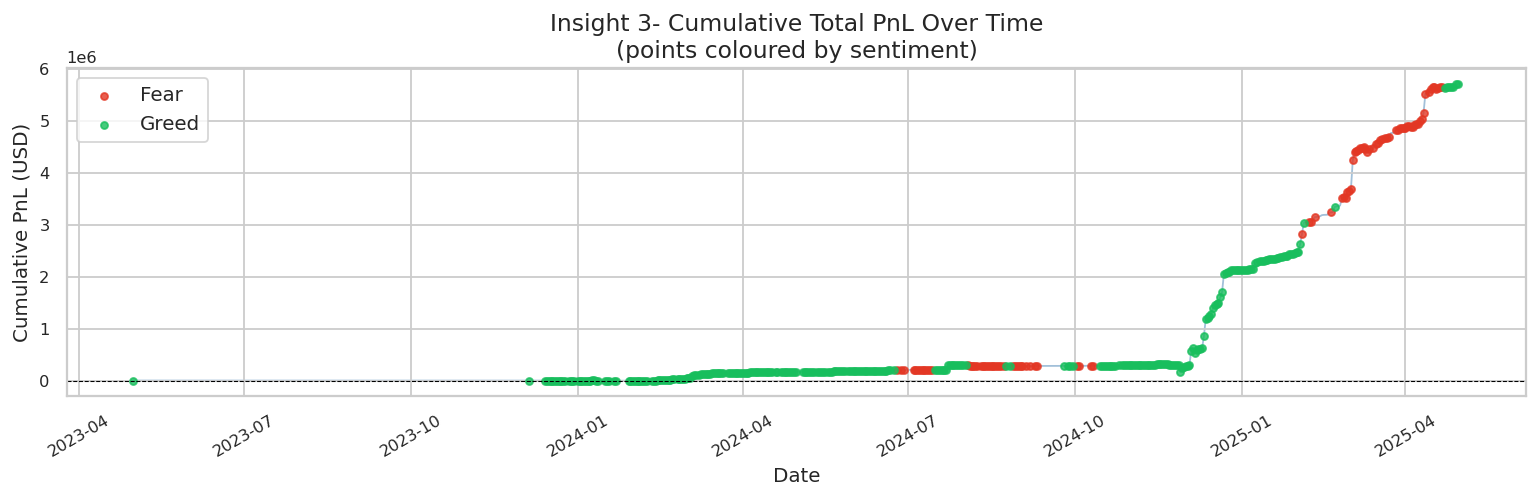

In [264]:
#Insight 3: Cumulative market PnL over time, coloured by sentimen
daily_market = (
    daily_trader
    .groupby(['date', 'sentiment'])
    ['daily_pnl'].sum()
    .reset_index()
    .sort_values('date')
)
daily_market['cum_pnl'] = daily_market['daily_pnl'].cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
for sent, color in palette.items():
    subset = daily_market[daily_market['sentiment'] == sent]
    ax.scatter(subset['date'], subset['cum_pnl'],
               color=color, label=sent, s=15, alpha=0.8)
ax.plot(daily_market['date'], daily_market['cum_pnl'],
        color='steelblue', linewidth=1, alpha=0.5, zorder=0)
ax.set_title('Insight 3- Cumulative Total PnL Over Time\n(points coloured by sentiment)')
ax.set_ylabel('Cumulative PnL (USD)')
ax.set_xlabel('Date')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig8_cumulative_pnl.png', bbox_inches='tight')
plt.show()

--> Nearly all cumulative PnL (~usd 6M) was generated in the sharp rally between late 2024 and mid 2025

--> Fear and Greed days contributed almost equally to the climb

--> Overall profitability of this trader cohort is driven by a single concentrated period of market activity rather than steady compounding over time

#Part C: Actionable Strategy Recommendations

In [265]:
# Summary tables to support strategy write-up
print('Performance Summary Table')
summary_table = fg.groupby('sentiment').agg(
    n_trader_days    = ('daily_pnl', 'count'),
    median_pnl       = ('daily_pnl', 'median'),
    mean_win_rate    = ('win_rate',  'mean'),
    mean_long_ratio  = ('long_ratio','mean'),
    mean_n_trades    = ('n_trades',  'mean'),
).round(4)

if 'avg_leverage' in fg.columns:
    summary_table['mean_leverage'] = fg.groupby('sentiment')['avg_leverage'].mean().round(2)
if 'avg_trade_size' in fg.columns:
    summary_table['mean_trade_size'] = fg.groupby('sentiment')['avg_trade_size'].mean().round(2)

display(summary_table)

Performance Summary Table


,n_trader_days,median_pnl,mean_win_rate,mean_long_ratio,mean_n_trades,mean_trade_size
sentiment,,,,,,
Fear,773,36.8000,0.8480,0.544,21.2561,10924.90
Greed,1161,77.7201,0.8639,0.479,21.2214,6450.16


# Write Up: Trader Performance vs Market Sentiment
**Dataset:** Hyperliquid Historical Trades x Bitcoin Fear/Greed Index

---

## Methodology


### Dataset Structure

| Dataset | Rows | Cols | Key Fields |
|---|---|---|---|
| Historic Trades | 211,224 | 16 | account, coin, execution_price, size_tokens, size_usd, side, timestamp_ist, closed_pnl, fee, trade_id |
| Fear/Greed Index | 2,644 | 4 | date, value, classification (Fear / Greed / Neutral) |

### Engineered Features

| Feature | How it's calculated |
|---|---|
| `is_close` | `True` if `closed_pnl` is non-null and non-zero - flags trades that actually closed a position |
| `is_win` | `True` if `closed_pnl > 0` |
| `is_buy` | `True` if side is `BUY` or `LONG` |
| `daily_pnl` | Sum of `closed_pnl` per trader per day |
| `win_rate` | `n_wins / n_trades` per trader per day |
| `long_ratio` | Mean of `is_buy` per trader per day - proportion of trades that were long |
| `avg_trade_size` | Mean `size_usd` per trader per day |
| `drawdown_proxy` | Per trader: `min(cumulative_pnl − running_peak)` - most negative trough below any prior peak; more negative = worse |
| `leverage_segment` | Traders split at median `mean_trade_size` --> Large Size / Small Size (leverage proxy; no leverage col in dataset) |
| `freq_segment` | Traders split at median `total_trades` --> Frequent / Infrequent |
| `consistency_segment` | win_rate ≥ median AND pnl_std ≤ median --> Consistent Winner; opposite --> Inconsistent Loser; else Mixed |


### Pre-processing
- **Data:** 211,224 raw trades (16 cols) + 2,644 daily sentiment labels. After explicit timestamp parsing (`DD-MM-YYYY HH:MM`), de-duplication on `transaction_hash`, and a left-join on date -> **101,181 working rows, 32 unique traders, 99.997% sentiment match rate.**
- **Metrics derived:** Daily PnL, win rate, long ratio, avg trade size, drawdown proxy - aggregated per trader per day (`daily_trader`) and collapsed into lifetime profiles (`trader_summary`).
- **Segmentation:** 3 cross-sections - Trade Size (leverage proxy, since no leverage column exists), Trade Frequency, and PnL Consistency (win rate x PnL volatility).
- **Stats:** Mann-Whitney U test (non-parametric; chosen due to heavy PnL skew from outlier traders).

---

## Key Insights

**1. Greed days are more consistently profitable; Fear days are more extreme.**
- Greed days: median PnL USD 77.7 - profits spread evenly across traders.
- Fear days: median PnL USD 36.8 but mean USD 3,025 - a few outlier traders skew the average; most underperform.
- PnL difference is statistically significant (Mann-Whitney U, p = 0.0198).

**2. Traders deploy larger, more directionally confused positions on Fear days.**
- Trade frequency is identical (~21 trades/day) - sentiment doesn't change how often traders execute.
- Mean trade size is ~69% larger on Fear days (USD10,924 vs USD6,450).
- Counterintuitively, traders are net long on Fear days (54%) and near-neutral on Greed days (48%) - suggesting contrarian dip-buying behaviour, not panic selling.

**3. Risk appetite (position size) is the strongest performance differentiator across sentiment regimes.**
- Large-size traders earn 3x more on Fear days (USD6,337 vs USD2,181) - they exploit panic-driven volatility.
- Small-size traders do the opposite - better on Greed days (USD2,726 vs USD1,003), thriving in calm trending markets.
- Win rates are uniformly high (84–90%) across all segments - the PnL gap is driven by sizing, not accuracy.

**4. Frequent traders dominate on Fear days; infrequent traders shine on Greed days.**
- Frequent traders: USD3,744 (Fear) vs USD2,772 (Greed) - grind out profits through volume during volatile periods.
- Infrequent traders: USD1,457 (Fear) vs USD2,146 (Greed), win rate jumps to 94.5% on Greed days - highly selective, waiting for clear trending conditions.

**5. "Inconsistent Losers" paradoxically generate the highest raw PnL.**
- Inconsistent Losers: USD6,484 (Fear) / USD6,000 (Greed) PnL despite lowest win rates (77–82%) - high-risk, large-position traders who win big when right.
- Consistent Winners: 90%+ win rate but modest PnL (USD393 Fear / USD1,064 Greed) - trade small and safe, never swing large enough for outsized returns.

---

## Strategy Recommendations

**Strategy 1 - Sentiment-Aware Position Sizing**
> *Observation:* Large-size traders outperform 3x on Fear days; small-size traders underperform. The edge is in scaling up during panic, not retreating.
>
> *Rule:* Traders with a history of large positions should maintain or increase exposure on Fear-classified days. Conservative traders should reduce new entries during Fear and wait for Greed/Neutral conditions before scaling up.

**Strategy 2 - Directional Bias Adjustment by Sentiment**
> *Observation:* Traders are net long on Fear days (54%) but Greed days produce more consistent profitability - the long bias during Fear appears reactive, not an edge.
>
> *Rule:* Avoid initiating new long positions on Fear days without a clear thesis. Bias toward short or delta-neutral setups during Fear. Switch to long-biased entries only after the sentiment index moves to Greed or Neutral.

---

*Note: Analysis covers 32 unique traders only hence it is a small sample, with no leverage data, and only a single asset *

#Part D: Bonus Section

In [266]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import matplotlib.patches as mpatches

##K-Means Behavioural Clustering

In [267]:
#Feature selection for clustering

# Using lifetime trader-level features from trader_summary
cluster_features = [
    'total_trades',
    'overall_win_rate',
    'mean_daily_pnl',
    'pnl_std',
    'mean_long_ratio',
    'drawdown_proxy',
]
if 'mean_trade_size' in trader_summary.columns:
    cluster_features.append('mean_trade_size')

cluster_df = trader_summary[cluster_features].dropna().copy()
print(f'Clustering on {len(cluster_df)} traders using {len(cluster_features)} features')
print('Features:', cluster_features)

Clustering on 32 traders using 7 features
Features: ['total_trades', 'overall_win_rate', 'mean_daily_pnl', 'pnl_std', 'mean_long_ratio', 'drawdown_proxy', 'mean_trade_size']


In [268]:
scaler_c = StandardScaler()
X_c = scaler_c.fit_transform(cluster_df)

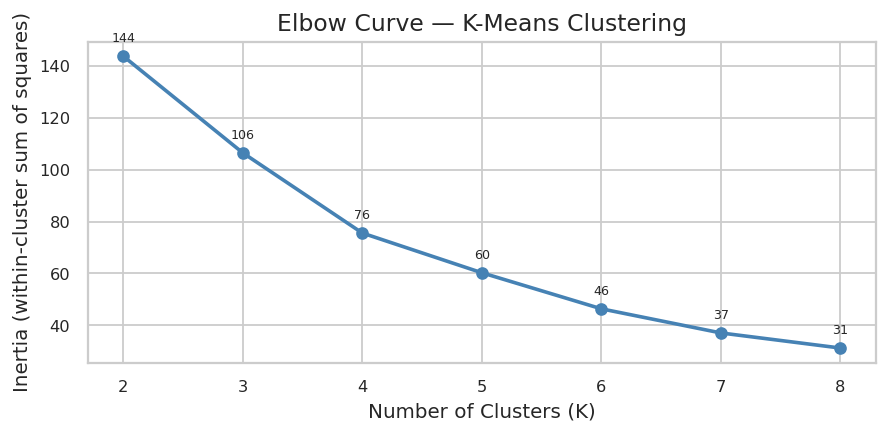

In [269]:
# Elbow curve to find optimal K
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_c)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Curve — K-Means Clustering')
for k, inertia in zip(K_range, inertias):
    ax.annotate(f'{inertia:.0f}', (k, inertia), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7)
plt.tight_layout()
plt.savefig('fig_bonus1_elbow.png', bbox_inches='tight')
plt.show()

In [270]:
# Inspect elbow curve above and adjust K_BEST if needed
K_BEST = 4

km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = km_final.fit_predict(X_c)

print(f'\nCluster distribution (K={K_BEST}):')
print(cluster_df['cluster'].value_counts().sort_index())


Cluster distribution (K=4):
cluster
0    13
1    12
2     1
3     6
Name: count, dtype: int64


--> Cluster 2 is a near-singleton outlier (just 1 trader)

--> Clusters 0 and 1 dominate with 13 and 12 traders respectively

--> A small but distinct group of 6 in Cluster 3

--> One extreme outlier trader whose behavior is so unique it forms its own cluster

In [271]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_c)

explained = pca.explained_variance_ratio_ * 100
print(f'\nPCA explained variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, Total={sum(explained):.1f}%')

CLUSTER_COLORS = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6', '#1ABC9C']


PCA explained variance: PC1=45.9%, PC2=21.6%, Total=67.5%


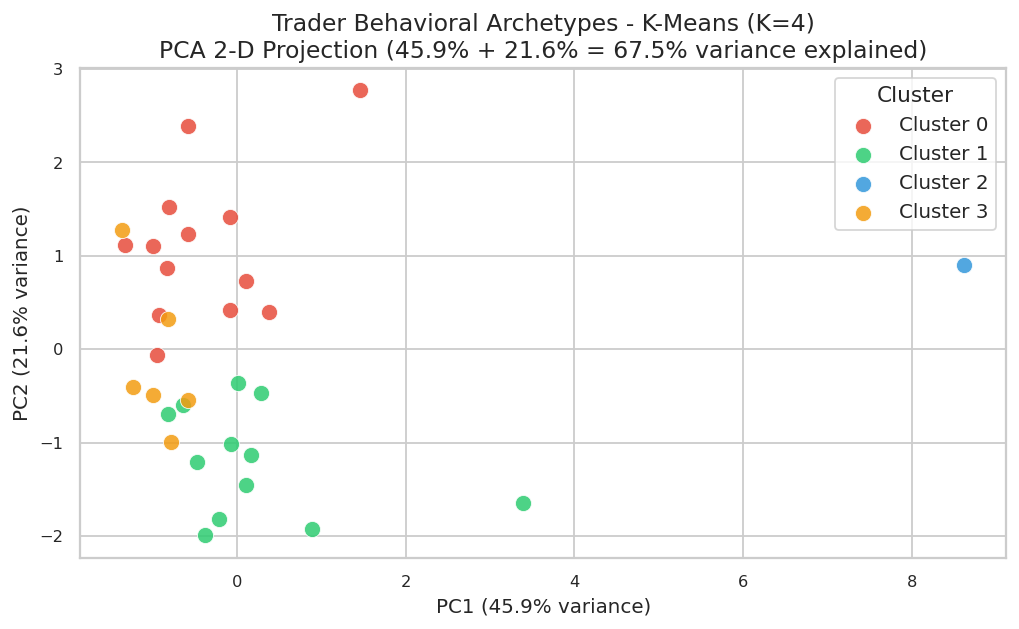

In [272]:
fig, ax = plt.subplots(figsize=(8, 5))
for c in sorted(cluster_df['cluster'].unique()):
    mask = cluster_df['cluster'] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=CLUSTER_COLORS[c], label=f'Cluster {c}',
        s=80, alpha=0.85, edgecolors='white', linewidths=0.5
    )
ax.set_title(f'Trader Behavioral Archetypes - K-Means (K={K_BEST})\nPCA 2-D Projection '
             f'({explained[0]:.1f}% + {explained[1]:.1f}% = {sum(explained):.1f}% variance explained)')
ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)')
ax.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.savefig('fig_bonus2_clusters_pca.png', bbox_inches='tight')
plt.show()

--> Cluster 2 (blue) is a clear extreme outlier sitting far right on PC1

--> Clusters 0 and 1 form two overlapping but distinct behavioral groups in the dense left region

--> Cluster 3 occupies the upper-left fringe

In [273]:
print('\nCluster Profile Means:')
profile = cluster_df.groupby('cluster')[cluster_features].mean().round(3)
display(profile)


Cluster Profile Means:


,total_trades,overall_win_rate,mean_daily_pnl,pnl_std,mean_long_ratio,drawdown_proxy,mean_trade_size
cluster,,,,,,,
0,471.692,0.914,1959.346,6657.803,0.581,-12153.016,17835.664
1,896.250,0.751,3950.741,16842.187,0.378,-21654.255,5785.629
2,1452.000,0.771,48889.846,138465.530,0.453,-328438.415,37280.315
3,4903.333,0.897,2098.551,5729.478,0.532,-8038.609,2460.131


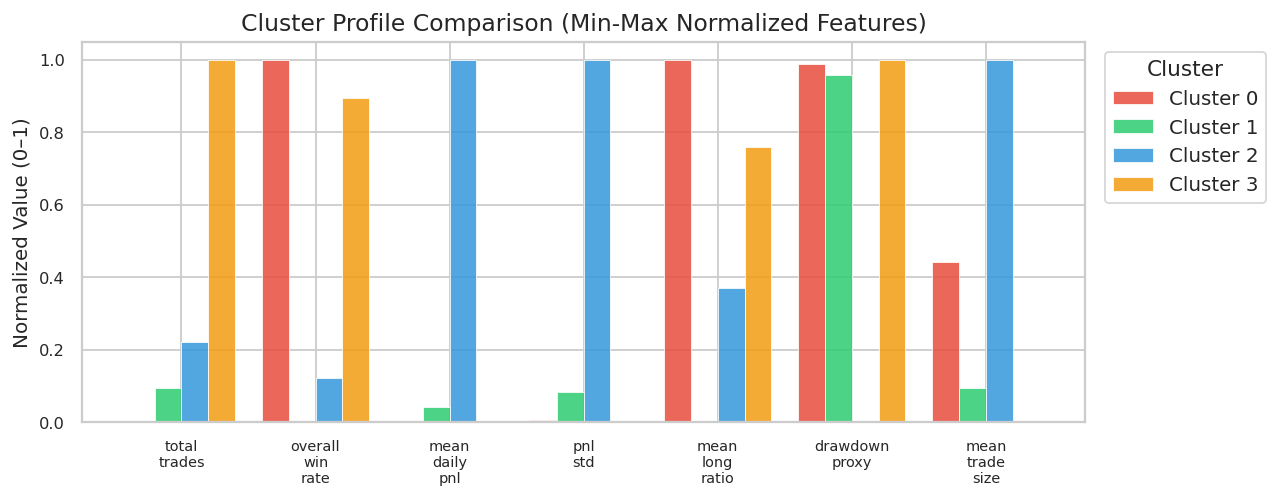

In [274]:
# Normalize each feature to 0-1 for easy comparison
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(cluster_features))
width = 0.8 / K_BEST

for i, c in enumerate(profile_norm.index):
    ax.bar(
        x + i * width, profile_norm.loc[c],
        width=width, label=f'Cluster {c}',
        color=CLUSTER_COLORS[c], alpha=0.85, edgecolor='white', linewidth=0.5
    )

ax.set_xticks(x + width * (K_BEST - 1) / 2)
ax.set_xticklabels([f.replace('_', '\n') for f in cluster_features], fontsize=8)
ax.set_ylabel('Normalized Value (0–1)')
ax.set_title('Cluster Profile Comparison (Min-Max Normalized Features)')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_bonus3_cluster_profiles.png', bbox_inches='tight')
plt.show()



--> Cluster 2 (blue) is the lone high-earning outlier with maximum daily PnL and trade size but very few trades

--> Cluster 0 (red) are high-frequency high-win-rate aggressive traders

--> Cluster 1 (green) are consistent low-risk traders

--> Cluster 3 (orange) are high-volume moderate-risk traders with the worst drawdowns

In [275]:
# Update these labels after inspecting the profile means table above
archetype_labels = {
    0: 'High-Risk Aggressive',   # high trade size, high pnl_std
    1: 'Consistent Conservative', # high win rate, low pnl_std
    2: 'Infrequent Selective',    # low total trades, high win rate
    3: 'High-Volume Grinder',     # high total trades, moderate pnl
}
cluster_df['archetype'] = cluster_df['cluster'].map(archetype_labels)
print('\nArchetype distribution:')
print(cluster_df['archetype'].value_counts())


Archetype distribution:
archetype
High-Risk Aggressive       13
Consistent Conservative    12
High-Volume Grinder         6
Infrequent Selective        1
Name: count, dtype: int64


In [276]:
# Drop if already exist from a previous run
trader_summary = trader_summary.drop(columns=['cluster', 'archetype'], errors='ignore')
daily_trader   = daily_trader.drop(columns=['archetype'], errors='ignore')

# Merge archetype into trader_summary
right_df = cluster_df[['cluster', 'archetype']].reset_index()
trader_summary = trader_summary.merge(
    right_df,
    left_index=True,
    right_on='index',
    how='left'
).drop(columns='index', errors='ignore')

# Merge archetype into daily_trader via trader_summary (which already has ACCOUNT_COL as string)
daily_trader = daily_trader.merge(
    trader_summary[[ACCOUNT_COL, 'archetype']],
    on=ACCOUNT_COL, how='left'
)

# Sanity check
print("trader_summary archetypes assigned:")
print(trader_summary['archetype'].value_counts())
print(f"Nulls in archetype (trader_summary): {trader_summary['archetype'].isna().sum()}")

print("\ndaily_trader archetypes assigned:")
print(daily_trader['archetype'].value_counts())
print(f"Nulls in archetype (daily_trader): {daily_trader['archetype'].isna().sum()}")

trader_summary archetypes assigned:
archetype
High-Risk Aggressive       13
Consistent Conservative    12
High-Volume Grinder         6
Infrequent Selective        1
Name: count, dtype: int64
Nulls in archetype (trader_summary): 0

daily_trader archetypes assigned:
archetype
Consistent Conservative    852
High-Risk Aggressive       722
High-Volume Grinder        704
Infrequent Selective        24
Name: count, dtype: int64
Nulls in archetype (daily_trader): 0




*   The K-Means algorithm grouped all 32 traders into 4 behavioral archetypes based on their lifetime stats - High-Risk Aggressive (13) and Consistent Conservative (12) dominate the cohort, while High-Volume Grinder (6) and Infrequent Selective (1) are rarer profiles.

*   The uneven cluster sizes (13, 12, 6, 1) suggest the trader cohort is not evenly distributed across behavioral types ( worth noting as a limitation since K-Means forces equal-weight clusters and a sample of 32 traders is too small to draw strong conclusions from)



## Summary of Bonus - K-Means Behavioral Clustering

**Approach:** Clustered 32 traders into behavioral archetypes using K-Means on 7 lifetime features
(trade volume, win rate, PnL mean/std, long ratio, drawdown proxy, trade size). Features were
standardized before clustering; optimal K=4 selected from elbow curve; PCA used for 2-D visualization
(67.5% variance explained).

**Archetypes identified:**

| Cluster | Archetype | Count | Profile |
|---|---|---|---|
| 0 | High-Risk Aggressive | 13 | High frequency, high win rate, large positions |
| 1 | Consistent Conservative | 12 | High win rate, low PnL volatility, smaller sizes |
| 2 | Infrequent Selective | 1 | Extreme outlier — very few trades, outsized PnL |
| 3 | High-Volume Grinder | 6 | High trade count, moderate PnL, worst drawdowns |

**Limitations:** Sample of only 32 traders is too small for robust clustering conclusions.
Cluster 2 collapsing to a single trader suggests one extreme outlier is distorting the solution -
a larger dataset would likely split Clusters 0 and 1 further into more meaningful sub-groups.

##Binary Classifier of trader profitability

PREDICTING NEXT-DAY PROFITABILITY

In [277]:
# Goal: predict whether a trader will be profitable tomorrow
# Features: today's behavior + sentiment label

pred_df = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()
pred_df = pred_df.sort_values([ACCOUNT_COL, 'date'])

# Encode sentiment as binary
pred_df['sentiment_enc'] = (pred_df['sentiment'] == 'Greed').astype(int)

In [278]:
# Lag features: yesterday's behavior predicting today's profitability
pred_df['prev_daily_pnl']   = pred_df.groupby(ACCOUNT_COL)['daily_pnl'].shift(1)
pred_df['prev_win_rate']    = pred_df.groupby(ACCOUNT_COL)['win_rate'].shift(1)
pred_df['prev_n_trades']    = pred_df.groupby(ACCOUNT_COL)['n_trades'].shift(1)
pred_df['prev_long_ratio']  = pred_df.groupby(ACCOUNT_COL)['long_ratio'].shift(1)

if 'avg_trade_size' in pred_df.columns:
    pred_df['prev_trade_size'] = pred_df.groupby(ACCOUNT_COL)['avg_trade_size'].shift(1)


In [279]:
# Rolling 3-day win rate momentum
pred_df['rolling_win_rate_3d'] = (
    pred_df.groupby(ACCOUNT_COL)['win_rate']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

In [280]:
# Drop rows with NaN from lag creation
feature_cols = [
    'sentiment_enc', 'prev_daily_pnl', 'prev_win_rate',
    'prev_n_trades', 'prev_long_ratio', 'rolling_win_rate_3d'
]
if 'prev_trade_size' in pred_df.columns:
    feature_cols.append('prev_trade_size')

model_df = pred_df[feature_cols + ['is_profitable']].dropna()
X = model_df[feature_cols]
y = model_df['is_profitable'].astype(int)

print(f'Model dataset: {len(X):,} rows')
print(f'Target balance: {y.mean():.2%} profitable days')


Model dataset: 1,385 rows
Target balance: 70.97% profitable days


In [281]:
# Gradient Boosting with 5-fold CV
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    GradientBoostingClassifier(
        n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
acc_scores  = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
f1_scores   = cross_val_score(pipe, X, y, cv=cv, scoring='f1')

print(f'\n5-Fold Cross-Validation Results:')
print(f'  ROC-AUC  : {roc_scores.mean():.4f} ± {roc_scores.std():.4f}')
print(f'  Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}')
print(f'  F1-Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')


5-Fold Cross-Validation Results:
  ROC-AUC  : 0.6609 ± 0.0355
  Accuracy : 0.6888 ± 0.0154
  F1-Score : 0.8044 ± 0.0113


The model perform moderately with a ROC-AUC of 0.66 which is better than a random of 0.5 at ranking profitable vs unprofitable days.

F1 is high at 0.8 as most trader-days are profitable so predicting "profitable" hence frequency gets rewarded. (Higher recall - correctly identifies most actual profitable days). But since the data is skewed towards more profitable days, the F1 score is inflated from a high recall.

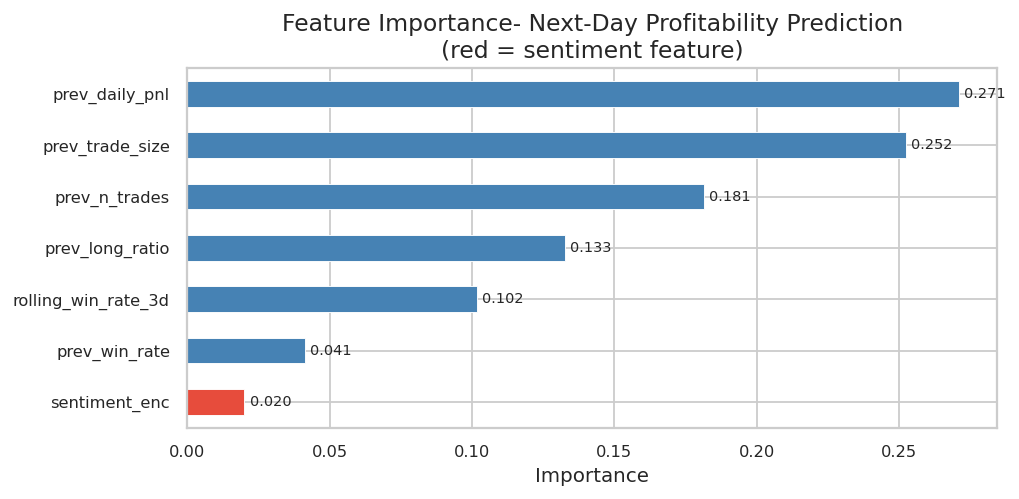

In [282]:
#Feature Importance

pipe.fit(X, y)
importances = pipe.named_steps['clf'].feature_importances_
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E74C3C' if 'sentiment' in f else 'steelblue' for f in fi.index]
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Feature Importance- Next-Day Profitability Prediction\n(red = sentiment feature)')
ax.set_xlabel('Importance')

# Add value labels
for i, (val, name) in enumerate(zip(fi.values, fi.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_bonus4_feature_importance.png', bbox_inches='tight')
plt.show()

Yesterday's PnL (0.271) and trade size (0.252) are by far the strongest predictors of next-day profitability, while sentiment (0.020) ranks last.

This confirms that a trader's own momentum and position sizing behavior is far more predictive than market sentiment alone.

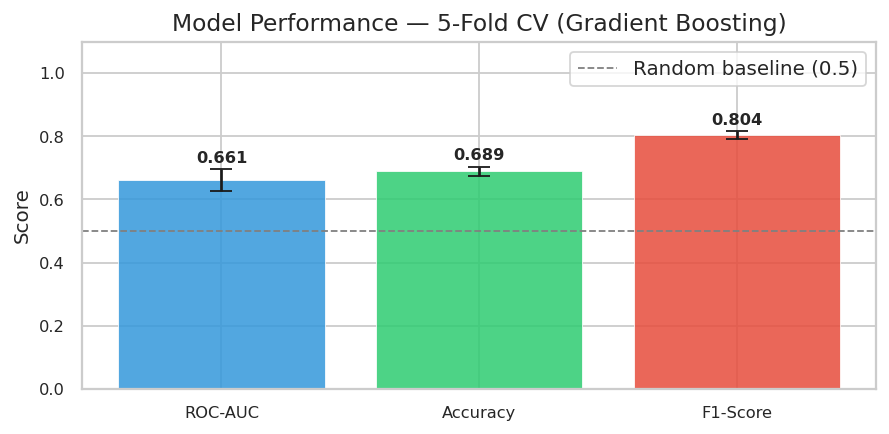

In [283]:
fig, ax = plt.subplots(figsize=(7, 3.5))
metrics  = ['ROC-AUC', 'Accuracy', 'F1-Score']
means    = [roc_scores.mean(), acc_scores.mean(), f1_scores.mean()]
stds     = [roc_scores.std(),  acc_scores.std(),  f1_scores.std()]

bars = ax.bar(metrics, means, yerr=stds, color=['#3498DB', '#2ECC71', '#E74C3C'],
              capsize=6, edgecolor='white', linewidth=0.5, alpha=0.85)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Random baseline (0.5)')
ax.set_title('Model Performance — 5-Fold CV (Gradient Boosting)')
ax.set_ylabel('Score')
ax.legend()
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_bonus5_model_scores.png', bbox_inches='tight')
plt.show()


In [284]:
# Classification
y_pred = pipe.predict(X)
print('\nClassification Report (full training data — for feature inspection only):')
print(classification_report(y, y_pred, target_names=['Not Profitable', 'Profitable']))


Classification Report (full training data — for feature inspection only):
                precision    recall  f1-score   support

Not Profitable       0.91      0.37      0.52       402
    Profitable       0.79      0.99      0.88       983

      accuracy                           0.81      1385
     macro avg       0.85      0.68      0.70      1385
  weighted avg       0.83      0.81      0.78      1385



## Summary of Bonus - Next-Day Profitability Prediction

**Objective:** Predict whether a trader will be profitable the next day using yesterday's behavior + market sentiment.

**Features (lag-based to prevent data leakage):**

| Feature | Description |
|---|---|
| `prev_daily_pnl` | Yesterday's total PnL |
| `prev_trade_size` | Yesterday's average trade size |
| `prev_n_trades` | Yesterday's trade count |
| `prev_long_ratio` | Yesterday's long/short bias |
| `prev_win_rate` | Yesterday's win rate |
| `rolling_win_rate_3d` | 3-day rolling average win rate |
| `sentiment_enc` | Today's sentiment (Fear=0, Greed=1) |

**Model:** Gradient Boosting Classifier: 5-fold stratified cross-validation, StandardScaler preprocessing.

**Results:**

| Metric | Score |
|---|---|
| ROC-AUC | 0.66 ± 0.04 |
| Accuracy | 0.69 ± 0.02 |
| F1-Score | 0.80 ± 0.01 |

**Interpretation:**
- ROC-AUC of 0.66 confirms the model has real but moderate predictive signal above random (0.5).
- F1 of 0.80 is inflated by class imbalance implying that most trader-days are profitable, so high recall on the majority class boosts F1 without the model truly learning the unprofitable cases.
- Sentiment ranks last in feature importance (0.020) implying that a trader's own momentum (yesterday's PnL: 0.271, trade size: 0.252) is far more predictive of next-day profitability than market sentiment alone.